In [8]:
from database.db import supabase
import matplotlib.pyplot as plt
import numpy as np
from modeling.day_tags import get_adjustment_weight
import datetime as dt

In [14]:
beetlejuice_id = "839450a1-599a-4c42-a3f9-8ef4d676cb33"
black_adam_id = "7dc84265-fa8b-42da-8b75-3626d37091d9"
conclave_id = "70deef7a-03b7-4001-b91e-10ea3cb6eb7f"
dune2_id = "94d9b521-84fc-4741-b5be-72b9e34c272f"
moana2_id = "3108df23-df0d-4b66-a7af-406125098986"
redone_id = "0421bf53-3795-41e1-93fb-5ab2cbdadfa6"

movie_id = redone_id

boxofficedays = (
    supabase.table("boxofficeday")
    .select("movie_id, date, revenue, movie_id (title)")
    .eq("movie_id", movie_id)
    .eq("is_preview", False)
    .order("date")
    .execute()
    .data
)

In [15]:
knn = supabase.rpc("knn", {"movie_id_og": movie_id, "k": 10, }).execute().data
# get the boxofficedays and movie info days for the knn
knn_ids: list[str] = [x["return_id"] for x in knn]

knn_boxofficedays = (
    supabase.table("boxofficeday")
    .select("*, movie_id, movie_id (title, id)")
    .in_("movie_id", knn_ids)
    .eq("is_preview", False)
    .order("movie_id")
    .order("date")
    .execute()
    .data
)

knn_by_movie_id = {}
for boxofficeday in knn_boxofficedays:
    bod_movie_id = boxofficeday["movie_id"]["id"]
    if bod_movie_id not in knn_by_movie_id:
        knn_by_movie_id[bod_movie_id] = []
    knn_by_movie_id[bod_movie_id].append(boxofficeday)

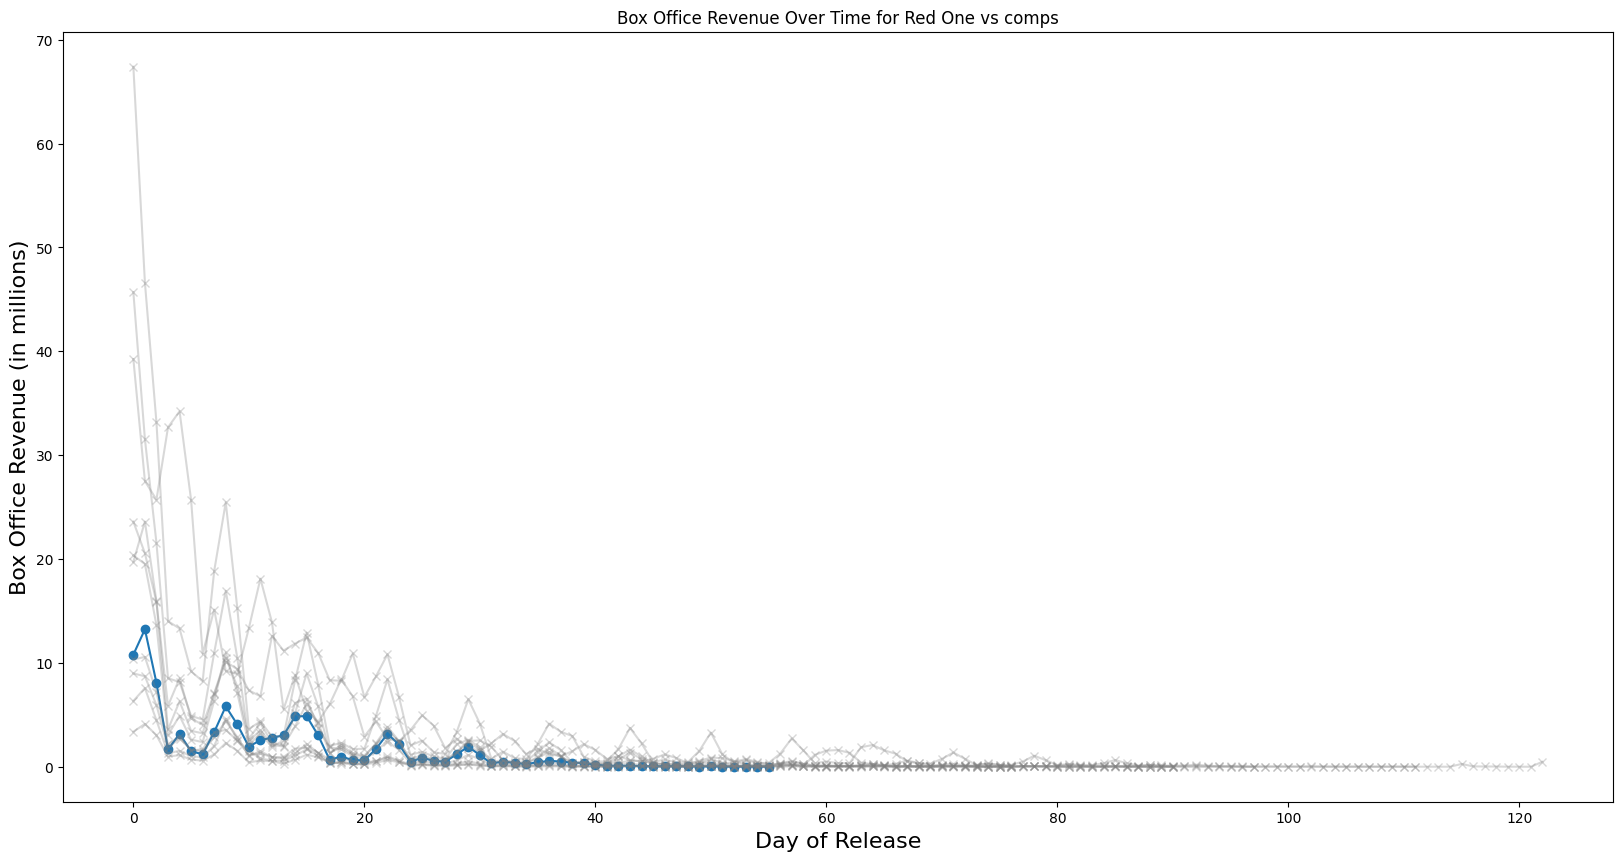

Cumulative MAPD vs median: nan for day 0
Cumulative MAPD vs median: 0.11923829648329663 for day 1
Cumulative MAPD vs median: 0.09029998137123213 for day 2
Cumulative MAPD vs median: 0.1302790225747171 for day 3
Cumulative MAPD vs median: 0.14720766624372775 for day 4
Cumulative MAPD vs median: 0.1422286210512522 for day 5
Cumulative MAPD vs median: 0.1274126610027577 for day 6
Cumulative MAPD vs median: 0.1291594583293652 for day 7
Cumulative MAPD vs median: 0.12175006516090445 for day 8
Cumulative MAPD vs median: 0.11134034440981691 for day 9
Cumulative MAPD vs median: 0.1146350278788733 for day 10
Cumulative MAPD vs median: 0.10641709251715324 for day 11
Cumulative MAPD vs median: 0.11584250393894985 for day 12
Cumulative MAPD vs median: 0.11372741794582238 for day 13
Cumulative MAPD vs median: 0.1117252304068466 for day 14
Cumulative MAPD vs median: 0.11857352739488129 for day 15
Cumulative MAPD vs median: 0.1136821885340965 for day 16
Cumulative MAPD vs median: 0.12423867284334052 

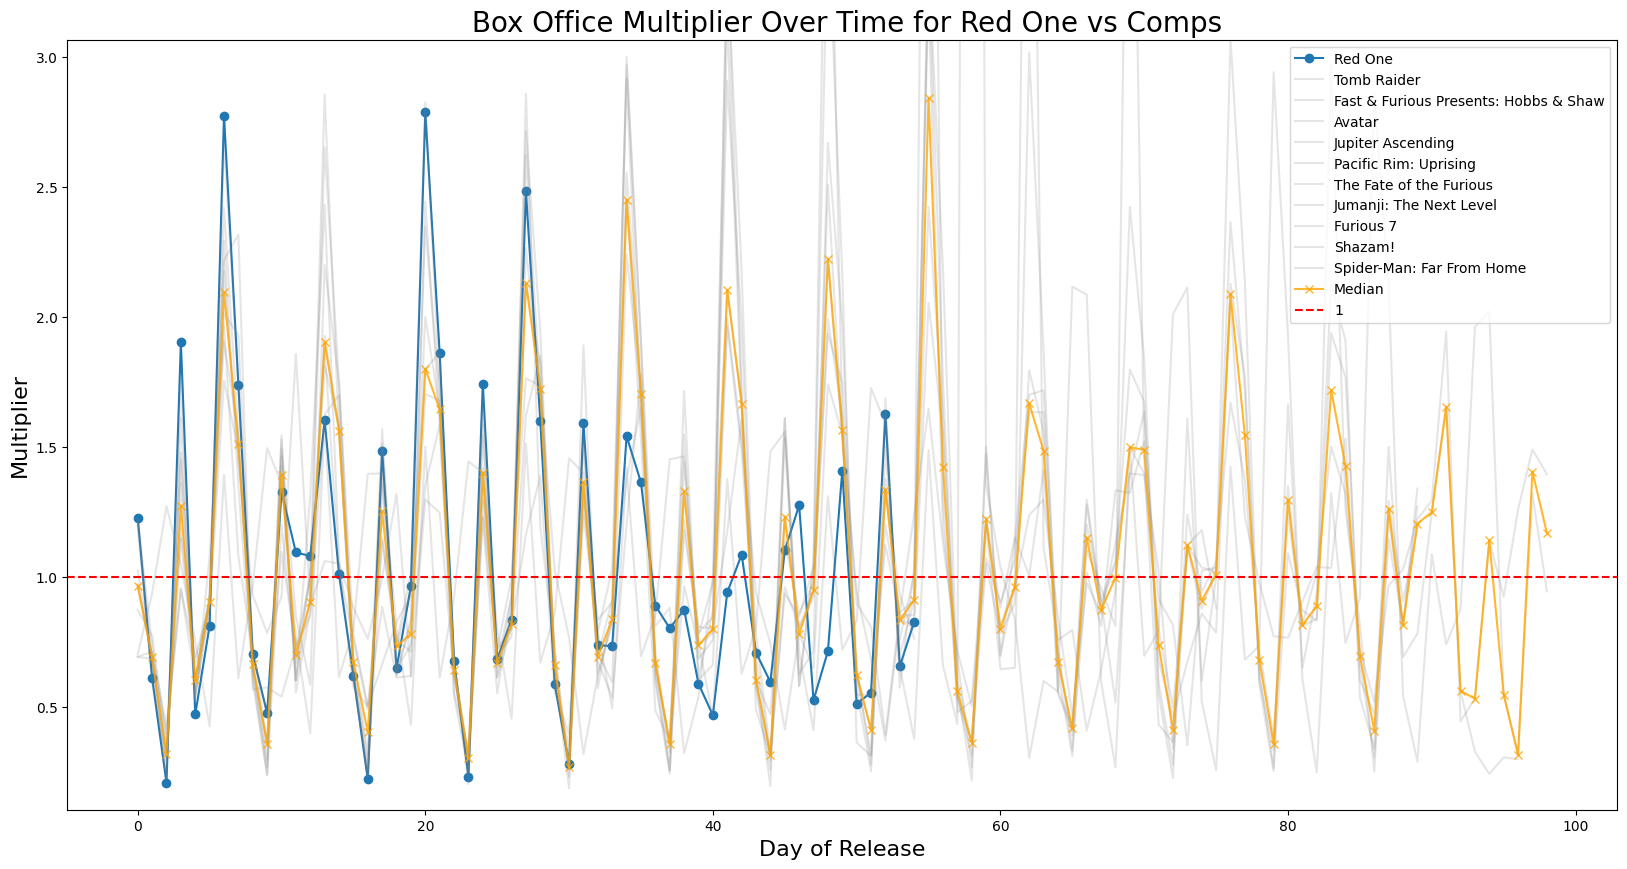

In [18]:
def plot_boxoffice(boxofficedays, knn_by_movie_id):
    fig, ax = plt.subplots(figsize=(20, 10))

    title = boxofficedays[0]["movie_id"]["title"]

    plt.plot(
        np.arange(len(boxofficedays)),
        [boxofficeday["revenue"] / 1_000_000 for boxofficeday in boxofficedays],
        marker="o",
        label=title
    )

    # Plot the KNN data
    for bods in knn_by_movie_id.values():
        bod_title = bods[0]["movie_id"]["title"]
        plt.plot(
            np.arange(len(bods)),
            [boxofficeday["revenue"] / 1_000_000 for boxofficeday in bods],
            marker="x",
            label=bod_title,
            color="gray",
            alpha=0.3
        )

    plt.xlabel("Day of Release", fontsize=16)
    plt.ylabel("Box Office Revenue (in millions)", fontsize=16)
    plt.title(f"Box Office Revenue Over Time for {title} vs comps")
    plt.show()

def plot_multipliers(boxofficedays, knn_by_movie_id, is_adjusted=False):
    fig, ax = plt.subplots(figsize=(20, 10))

    movie_mults = [day["revenue"] / boxofficedays[i - 1]["revenue"] for i, day in enumerate(boxofficedays[1:100], 1)]
    title=boxofficedays[0]["movie_id"]["title"]
    plt.plot(
        np.arange(len(movie_mults)),
        movie_mults,
        marker="o",
        label=title
    )

    mults_by_day: list[list[float]] = []
    for i in range(100):
        mults_by_day.append([])

    # Plot the KNN data
    for bod in knn_by_movie_id.values():
        bod_title = bod[0]["movie_id"]["title"]
        mults = [day["revenue"] / bod[i - 1]["revenue"] for i, day in enumerate(bod[1:100], 1)]
        plt.plot(
            np.arange(len(mults)),
            mults,
            label=bod_title,
            color="gray",
            alpha=0.2
        )

        for i in range(99):
            if len(mults) > i:
                mults_by_day[i].append(mults[i])

    # plot the medians
    medians = [np.median(mults) for mults in mults_by_day]
    plt.plot(
        np.arange(len(mults_by_day)),
        medians,
        marker="x",
        label="Median",
        color="orange",
        alpha=0.8
    )

    for i in range(50):
        mapd = np.mean([abs((movie_mults[i] - medians[i]) / (movie_mults[i] + medians[i])) for i in range(i)])

        print(f"Cumulative MAPD vs median: {mapd} for day {i}")

    # plot the means
    # plt.plot(
    #     np.arange(len(mults_by_day)),
    #     [np.mean(mults) for mults in mults_by_day],
    #     marker="o",
    #     label="Mean",
    #     color="purple",
    #     alpha=0.5
    # )

    plt.axhline(1, color="red", linestyle="--", label="1")

    plt.ylim(min(movie_mults) * 0.5, max(movie_mults) * 1.1)
    plt.xlabel("Day of Release", fontsize=16)
    plt.ylabel("Multiplier", fontsize=16)
    plt.title(f"{'Adjusted' if is_adjusted else ''} Box Office Multiplier Over Time for {title} vs Comps", fontsize=20)
    plt.legend(loc="upper right")
    plt.show()

plot_boxoffice(boxofficedays, knn_by_movie_id)
plot_multipliers(boxofficedays, knn_by_movie_id)

Cumulative MAPD vs median: nan for day 0
Cumulative MAPD vs median: 0.09667501845515909 for day 1
Cumulative MAPD vs median: 0.07406459295808795 for day 2
Cumulative MAPD vs median: 0.1266341469618617 for day 3
Cumulative MAPD vs median: 0.11965425430652027 for day 4
Cumulative MAPD vs median: 0.11096717786149249 for day 5
Cumulative MAPD vs median: 0.10730920302310816 for day 6
Cumulative MAPD vs median: 0.12353223197314551 for day 7
Cumulative MAPD vs median: 0.13774399858924966 for day 8
Cumulative MAPD vs median: 0.1255620409934733 for day 9
Cumulative MAPD vs median: 0.14975090409662825 for day 10
Cumulative MAPD vs median: 0.14331883405569365 for day 11
Cumulative MAPD vs median: 0.1353702663081416 for day 12
Cumulative MAPD vs median: 0.13715676426887283 for day 13
Cumulative MAPD vs median: 0.1416232355261544 for day 14
Cumulative MAPD vs median: 0.13429254590613562 for day 15
Cumulative MAPD vs median: 0.12652849206173147 for day 16
Cumulative MAPD vs median: 0.121361159055800

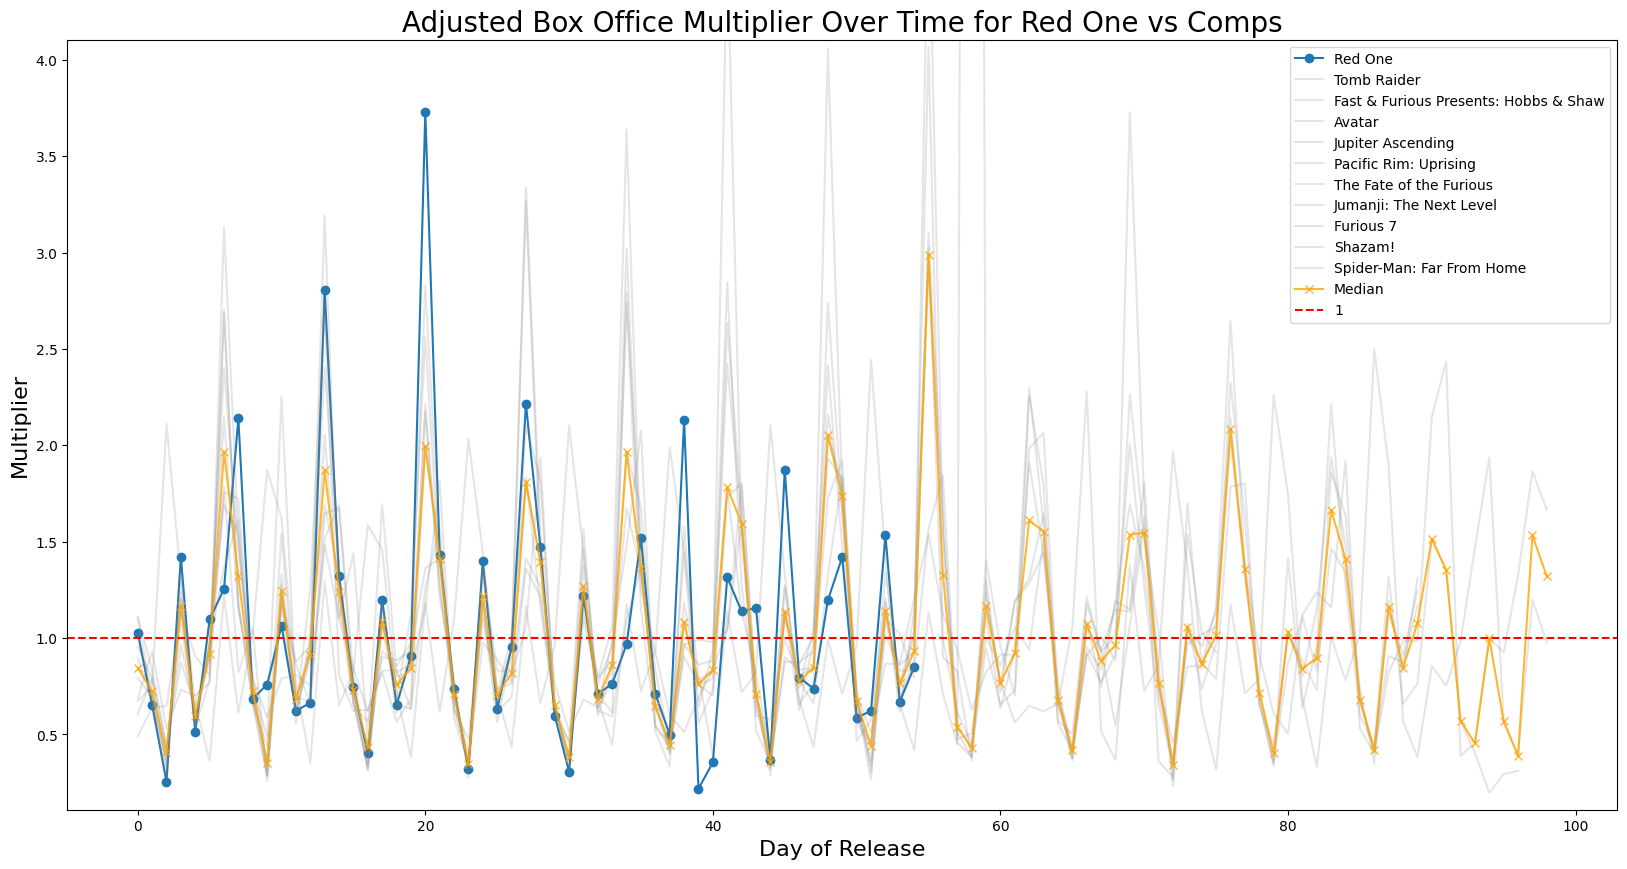

In [21]:
adjusted_boxofficedays = []
adjusted_knn_by_movie_id = {}

for day in boxofficedays:
    day_date = dt.datetime.strptime(day["date"], "%Y-%m-%d").date()
    adjustment = get_adjustment_weight(day_date)
    adjusted_revenue = day["revenue"] / adjustment

    adjusted_boxofficedays.append({
        "movie_id": day["movie_id"],
        "date": day["date"],
        "revenue": adjusted_revenue,
        "adjustment": adjustment
    })

for bod_id, bods in knn_by_movie_id.items():
    adjusted_knn_by_movie_id[bod_id] = []
    for day in bods:
        day_date = dt.datetime.strptime(day["date"], "%Y-%m-%d").date()
        adjustment = get_adjustment_weight(day_date)
        adjusted_revenue = day["revenue"] / adjustment

        adjusted_knn_by_movie_id[bod_id].append({
            "movie_id": day["movie_id"],
            "date": day["date"],
            "revenue": adjusted_revenue,
            "adjustment": adjustment
        })

plot_multipliers(adjusted_boxofficedays, adjusted_knn_by_movie_id, is_adjusted=True)